# 06 Appendix Heterogeneous Signal-Loss Reversal

Appendix experiment for Appendix B.3. It gives a concrete construction where two signal-loss mechanisms have the same aggregate degraded lift but certify different segments.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "privacy_robust_incrementality_measurement" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "code" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import ProjectPaths
paths = ProjectPaths.from_cwd(PROJECT_ROOT)
paths


ProjectPaths(project_root=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement'), code_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code'), data_dir=PosixPath('/home/apex/Documents/ranking_sys/data'), artifact_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts'), figure_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/figures'), table_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/tables'), workspace_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/workspace'))

In [2]:
from experiments import heterogeneous_signal_loss_reversal
from tables import write_table
import matplotlib.pyplot as plt

reversal = heterogeneous_signal_loss_reversal()
write_table(reversal, paths.table_dir / "heterogeneous_reversal_appendix.csv")
reversal


,world,segment_1_clean_treat,segment_2_clean_treat,segment_1_retention,segment_2_retention,segment_1_degraded_treat,segment_2_degraded_treat,aggregate_clean_treat,aggregate_degraded_treat,segment_1_lower,segment_1_upper,segment_1_decision,segment_2_lower,segment_2_upper,segment_2_decision,threshold,certified_segment
0,u,1.0,0.0,0.5,1.0,0.5,0.0,0.5,0.25,0.5,1.0,certify,0.0,0.0,reject,0.25,segment_1
1,u_prime,0.0,1.0,1.0,0.5,0.0,0.5,0.5,0.25,0.0,0.0,reject,0.5,1.0,certify,0.25,segment_2


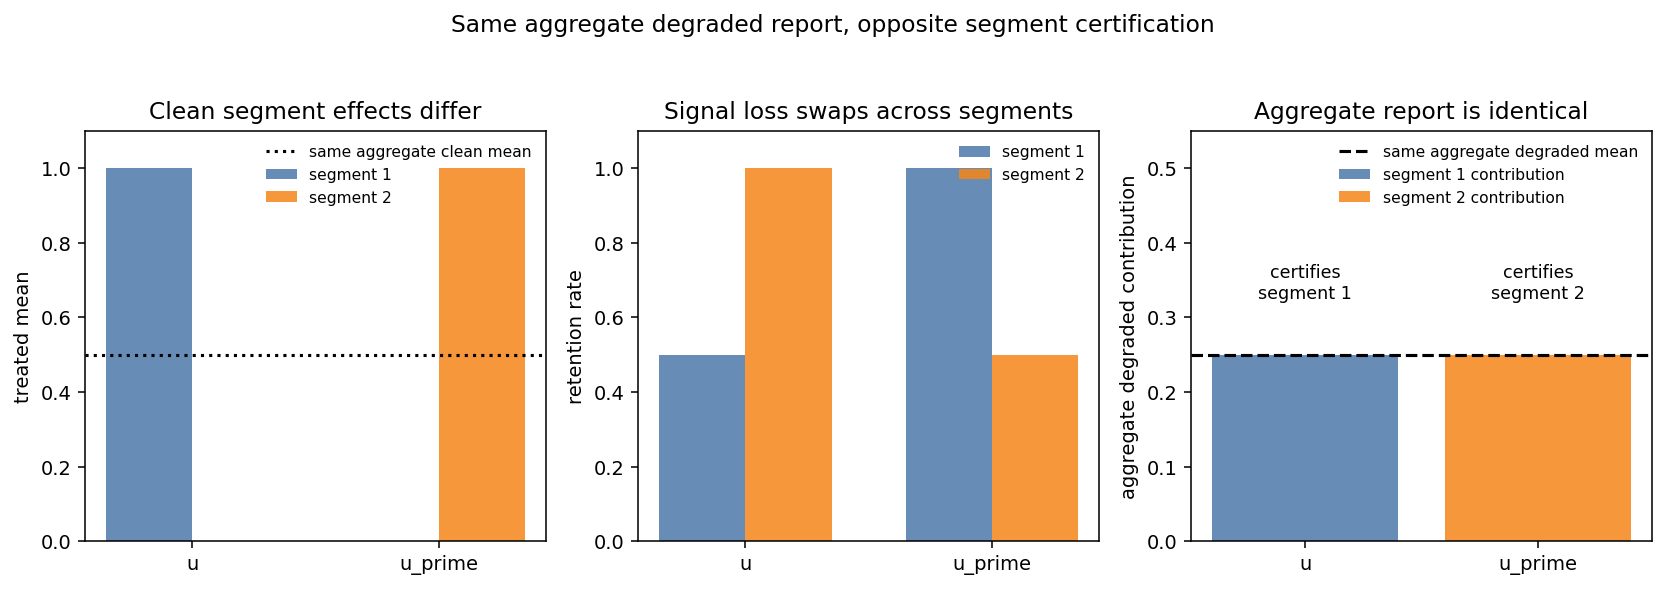

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=140)
worlds = reversal["world"]
colors = {"segment_1": "#4c78a8", "segment_2": "#f58518"}
x = range(len(worlds))
width = 0.35

axes[0].bar([i - width/2 for i in x], reversal["segment_1_clean_treat"], width=width, label="segment 1", color=colors["segment_1"], alpha=0.85)
axes[0].bar([i + width/2 for i in x], reversal["segment_2_clean_treat"], width=width, label="segment 2", color=colors["segment_2"], alpha=0.85)
axes[0].set_xticks(list(x), worlds)
axes[0].axhline(reversal["aggregate_clean_treat"].iloc[0], color="black", linestyle=":", linewidth=1.6, label="same aggregate clean mean")
axes[0].set_title("Clean segment effects differ")
axes[0].set_ylabel("treated mean")
axes[0].set_ylim(0, 1.1)
axes[0].legend(frameon=False, fontsize=8)

axes[1].bar([i - width/2 for i in x], reversal["segment_1_retention"], width=width, label="segment 1", color=colors["segment_1"], alpha=0.85)
axes[1].bar([i + width/2 for i in x], reversal["segment_2_retention"], width=width, label="segment 2", color=colors["segment_2"], alpha=0.85)
axes[1].set_xticks(list(x), worlds)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Signal loss swaps across segments")
axes[1].set_ylabel("retention rate")
axes[1].legend(frameon=False, fontsize=8)

seg1_report = 0.5 * reversal["segment_1_degraded_treat"]
seg2_report = 0.5 * reversal["segment_2_degraded_treat"]
axes[2].bar(worlds, seg1_report, label="segment 1 contribution", color=colors["segment_1"], alpha=0.85)
axes[2].bar(worlds, seg2_report, bottom=seg1_report, label="segment 2 contribution", color=colors["segment_2"], alpha=0.85)
axes[2].axhline(reversal["aggregate_degraded_treat"].iloc[0], color="black", linestyle="--", linewidth=1.6, label="same aggregate degraded mean")
for i, row in reversal.iterrows():
    axes[2].text(i, 0.32, f"certifies\n{row['certified_segment'].replace('_', ' ')}", ha="center", va="bottom", fontsize=9)
axes[2].set_ylim(0, 0.55)
axes[2].set_title("Aggregate report is identical")
axes[2].set_ylabel("aggregate degraded contribution")
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle("Same aggregate degraded report, opposite segment certification", y=1.04)
plt.tight_layout()
plt.savefig(paths.figure_dir / "heterogeneous_reversal_appendix.png", bbox_inches="tight")
plt.show()
